In [1]:
import os

# Download do dataset caso não exista localmente (Útil para Google Colab)
csv_file = 'timeseries_seed_101.csv'
if not os.path.exists(csv_file):
    print(f"Baixando {csv_file} do GitHub...")
    !wget -q https://raw.githubusercontent.com/rafaelwilliamm/glaukopis/main/timeseries_analysis/timeseries_seed_101.csv
    print("Download concluído.")
else:
    print(f"{csv_file} já existe localmente.")

timeseries_seed_101.csv já existe localmente.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaelwilliamm/glaukopis/blob/main/timeseries_analysis/Cap5_Ferramentas_Forecasting_Radar.ipynb)

# Capítulo 5 — Ferramentas de Forecasting
### Aplicação ao Engajamento Radar BVR (Simulador Glaukopis)

**Referência**: Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. [otexts.com/fpp3/toolbox.html](https://otexts.com/fpp3/toolbox.html)

---

Este notebook implementa o **Capítulo 5 do FPP3** — a *caixa de ferramentas do forecaster* — aplicado aos dados de engajamento BVR do simulador **Glaukopis**. O objetivo é estabelecer **benchmarks de previsão** para as variáveis cinemáticas do radar e avaliar sua qualidade por meio de diagnósticos de resíduos e validação cruzada.

#### Mapeamento Capítulo 5 → Dados Radar

| Conceito FPP3 | Variável Radar | Interpretação Física |
|---------------|----------------|----------------------|
| **Método Ingênuo (§5.2)** | `TGT_01_pos_x` | Persistência cinemática: a posição futura ≈ posição atual |
| **Método Drift (§5.2)** | `TGT_01_pos_x` | Extrapolação linear da trajetória balística |
| **Resíduos (§5.4)** | `snr_db` | Erro de previsão ≈ ruído de medição não-modelado |
| **MASE (§5.8)** | Todas | Métrica normalizada: MASE < 1 → modelo supera o Naïve |
| **TSCV (§5.10)** | `TGT_01_pos_x`, `snr_db` | Robustez em diferentes fases do engajamento |

#### Seções Cobertas
- §5.1 Fluxo de trabalho do forecasting
- §5.2 Métodos simples: Mean, Naïve, Drift
- §5.3 Valores ajustados e resíduos
- §5.4 Diagnósticos de resíduos (ACF, Ljung-Box)
- §5.8 Avaliação de acurácia (MAE, RMSE, MASE)
- §5.10 Validação cruzada de séries temporais (TSCV)

> **Nota**: Seasonal Naïve (§5.2) não se aplica — dados de radar não possuem sazonalidade periódica. Seções §5.5–5.7 (distribuições/intervalos de predição) são contextualizadas, mas não implementadas, pois requerem modelos paramétricos dos capítulos seguintes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Configuração global de estilo
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de cores consistente (herdada + extensões para Cap5)
COLORS = {
    'trend': '#2ecc71',       'noise': '#9b59b6',
    'rcs': '#e74c3c',         'interceptor': '#e67e22',
    'gforce': '#3498db',      'miss': '#1abc9c',
    'acf_bar': '#2c3e50',     'original': '#999999',
    'remainder': '#CC79A7',
    # Novas cores — Cap5 Forecasting
    'forecast_mean': '#E69F00',
    'forecast_naive': '#56B4E9',
    'forecast_drift': '#009E73',
    'residual': '#CC79A7',
    'train': '#2c3e50',
    'test': '#e74c3c',
    'ci_band': '#bdc3c7',
}
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 0. Carregamento e Preparação dos Dados

In [3]:
df = pd.read_csv('timeseries_seed_101.csv')
print(f"Dimensões: {df.shape[0]} amostras × {df.shape[1]} variáveis")
print(f"Intervalo temporal: {df['time'].min()}s a {df['time'].max()}s")
print(f"Taxa de amostragem: {1 / df['time'].diff().median():.0f} Hz")
print(f"\nFases do track_status:")
print(df['track_status'].value_counts().to_string())
df.head(3)

Dimensões: 316 amostras × 19 variáveis
Intervalo temporal: 0.0s a 31.5s
Taxa de amostragem: 10 Hz

Fases do track_status:
track_status
CONFIRMED    310
TENTATIVE      4
SEARCHING      2


,time,random_seed,scenario_id,TGT_01_pos_x,TGT_01_pos_y,TGT_01_pos_z,INTERCEPTOR_01_pos_x,INTERCEPTOR_01_pos_y,INTERCEPTOR_01_pos_z,snr_db,miss_distance_m,g_force,track_status,missile_launched,TGT_01_rcs_instantaneous,TGT_01_rcs_mean,TGT_01_sigma_min,TGT_01_sigma_max,TGT_01_display_label
0,0.0,101,SU27_01_43km_head-on,42960.0,2005.0,3998.0,0.0,0.0,0.0,-0.73,0.0,0.0,SEARCHING,False,2.44600,3.36685,3.0,15.0,Su-27 Flanker — σ=3–15 m²
1,0.1,101,SU27_01_43km_head-on,42920.0,2010.0,3996.0,0.0,0.0,0.0,-7.25,0.0,0.0,SEARCHING,False,0.30000,3.36753,3.0,15.0,Su-27 Flanker — σ=3–15 m²
2,0.2,101,SU27_01_43km_head-on,42880.0,2015.0,3994.0,0.0,0.0,0.0,15.02,0.0,0.0,TENTATIVE,False,3.89386,3.36821,3.0,15.0,Su-27 Flanker — σ=3–15 m²


Dados CONFIRMED: 310 amostras (0.6s – 31.5s)


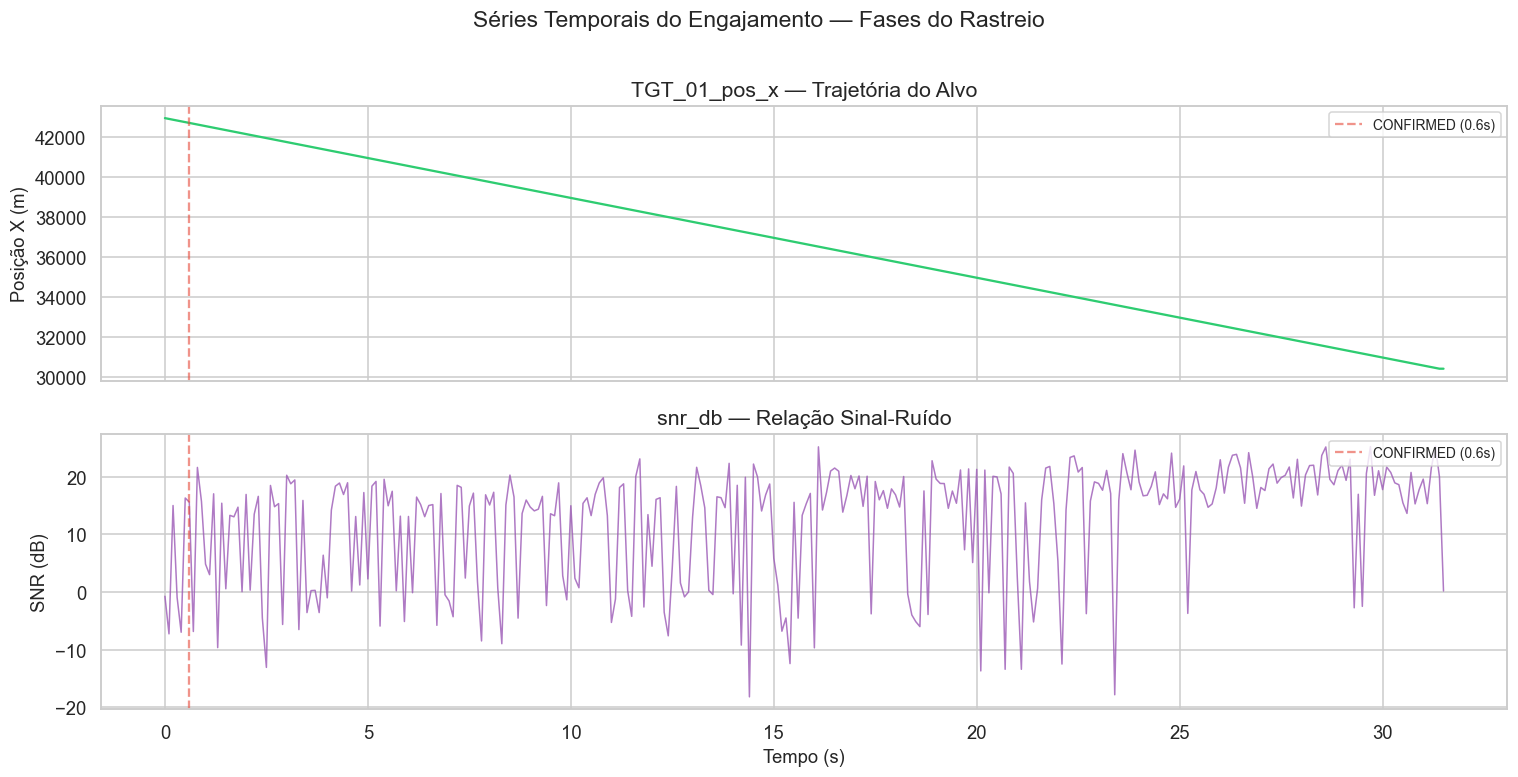

In [4]:
# Filtrar apenas fase CONFIRMED (rastreio estável pós-detecção)
df_conf = df[df['track_status'] == 'CONFIRMED'].copy().reset_index(drop=True)
print(f"Dados CONFIRMED: {len(df_conf)} amostras ({df_conf['time'].min():.1f}s – {df_conf['time'].max():.1f}s)")

# Visualização da série com anotação de fases
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Posição do alvo
axes[0].plot(df['time'], df['TGT_01_pos_x'], color=COLORS['trend'], lw=1.5)
axes[0].set_ylabel('Posição X (m)')
axes[0].set_title('TGT_01_pos_x — Trajetória do Alvo')

# SNR
axes[1].plot(df['time'], df['snr_db'], color=COLORS['noise'], lw=1, alpha=0.8)
axes[1].set_ylabel('SNR (dB)')
axes[1].set_title('snr_db — Relação Sinal-Ruído')
axes[1].set_xlabel('Tempo (s)')

# Anotar fases
t_confirmed = df[df['track_status'] == 'CONFIRMED']['time'].min()
for ax in axes:
    ax.axvline(t_confirmed, color=COLORS['test'], ls='--', alpha=0.6, label=f'CONFIRMED ({t_confirmed:.1f}s)')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Séries Temporais do Engajamento — Fases do Rastreio', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 1. O Fluxo de Trabalho do Forecasting (§5.1)

O FPP3 define um fluxo **tidy** para forecasting:

```
Dados → Modelo → Resíduos → Diagnóstico → Previsão → Avaliação
```

No contexto radar, o "modelo" mais simples é a **persistência cinemática** (Naïve): assumir que o alvo mantém sua posição/estado atual. Métodos mais sofisticados (filtro Alpha-Beta, Kalman) devem **superar** esses benchmarks para justificar sua complexidade.

### Separação Treino/Teste

Dividimos a série CONFIRMED em ~80% treino / ~20% teste. A separação é **estritamente temporal** — nunca usamos dados futuros para treinar.

Treino: 248 amostras (0.6s – 25.3s)
Teste:  62 amostras (25.4s – 31.5s)
Razão:  80.0% / 20.0%


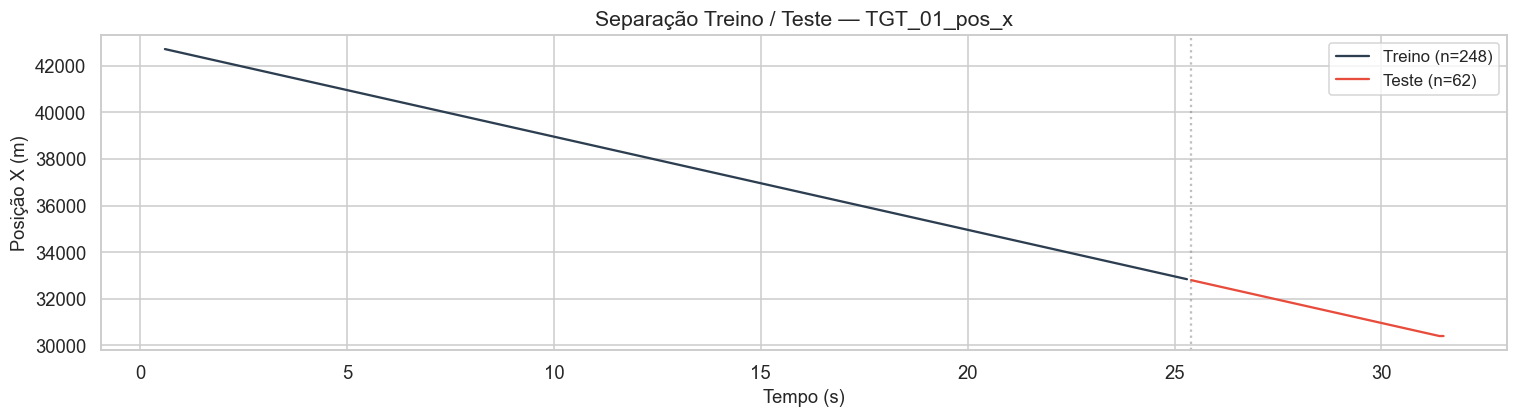

In [5]:
# Separação treino/teste (80/20)
split_ratio = 0.8
split_idx = int(len(df_conf) * split_ratio)
train = df_conf.iloc[:split_idx]
test = df_conf.iloc[split_idx:]

h = len(test)  # horizonte de previsão
T = len(train)  # tamanho do treino

print(f"Treino: {T} amostras ({train['time'].iloc[0]:.1f}s – {train['time'].iloc[-1]:.1f}s)")
print(f"Teste:  {h} amostras ({test['time'].iloc[0]:.1f}s – {test['time'].iloc[-1]:.1f}s)")
print(f"Razão:  {T/(T+h):.1%} / {h/(T+h):.1%}")

# Visualização da separação
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['time'], train['TGT_01_pos_x'], color=COLORS['train'], lw=1.5, label=f'Treino (n={T})')
ax.plot(test['time'], test['TGT_01_pos_x'], color=COLORS['test'], lw=1.5, label=f'Teste (n={h})')
ax.axvline(test['time'].iloc[0], color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Posição X (m)')
ax.set_title('Separação Treino / Teste — TGT_01_pos_x')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 2. Métodos Simples de Forecasting (§5.2)

Os **benchmarks** contra os quais qualquer modelo deve ser comparado:

| Método | Fórmula | Interpretação Radar |
|--------|---------|---------------------|
| **Mean** | $\hat{y}_{T+h\|T} = \bar{y}$ | Posição média histórica (irreal para alvos em movimento) |
| **Naïve** | $\hat{y}_{T+h\|T} = y_T$ | Persistência: alvo "congela" na última posição observada |
| **Drift** | $\hat{y}_{T+h\|T} = y_T + h \cdot \frac{y_T - y_1}{T-1}$ | Extrapolação linear da trajetória (modelo balístico simples) |

> **Nota**: O **Seasonal Naïve** ($\hat{y}_{T+h|T} = y_{T+h-m(k+1)}$) não se aplica, pois dados de engajamento radar não possuem periodicidade sazonal fixa.

In [6]:
# ── Funções de Forecasting ──

def forecast_mean(train_vals, h):
    """Mean method: previsão = média de todos os dados de treino."""
    return np.full(h, train_vals.mean())

def forecast_naive(train_vals, h):
    """Naïve method: previsão = último valor observado."""
    return np.full(h, train_vals.iloc[-1])

def forecast_drift(train_vals, h):
    """Drift method: extrapolação linear do primeiro ao último valor."""
    T = len(train_vals)
    slope = (train_vals.iloc[-1] - train_vals.iloc[0]) / (T - 1)
    return train_vals.iloc[-1] + np.arange(1, h + 1) * slope

# ── Funções de Fitted Values (in-sample, one-step-ahead) ──

def fitted_mean(train_vals):
    """Fitted: média expansível defasada em 1 passo."""
    return train_vals.expanding().mean().shift(1)

def fitted_naive(train_vals):
    """Fitted: valor anterior (random walk)."""
    return train_vals.shift(1)

def fitted_drift(train_vals):
    """Fitted: y_{t-1} + slope acumulado até t-1."""
    fitted = pd.Series(np.nan, index=train_vals.index)
    for i in range(1, len(train_vals)):
        if i == 1:
            fitted.iloc[i] = train_vals.iloc[0]
        else:
            slope = (train_vals.iloc[i-1] - train_vals.iloc[0]) / (i - 1)
            fitted.iloc[i] = train_vals.iloc[i-1] + slope
    return fitted

METHODS = {
    'Mean':  {'forecast': forecast_mean,  'fitted': fitted_mean,  'color': COLORS['forecast_mean']},
    'Naïve': {'forecast': forecast_naive, 'fitted': fitted_naive, 'color': COLORS['forecast_naive']},
    'Drift': {'forecast': forecast_drift, 'fitted': fitted_drift, 'color': COLORS['forecast_drift']},
}
print("Funções de forecasting definidas.")

Funções de forecasting definidas.


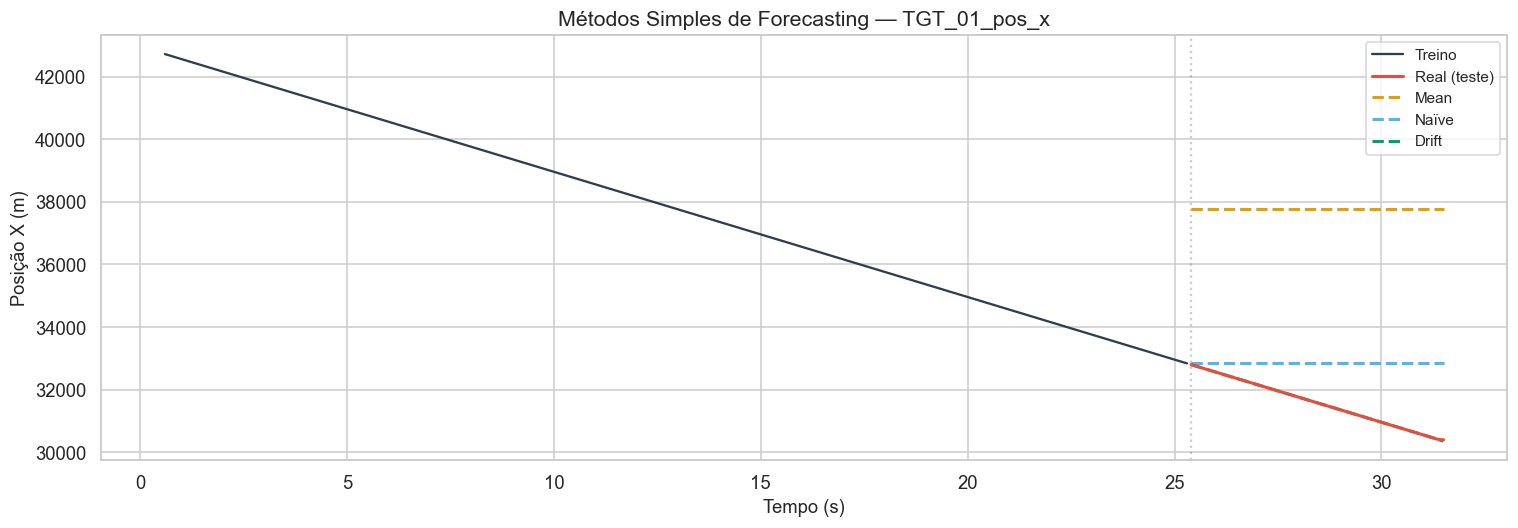

In [7]:
# ── Previsões para TGT_01_pos_x ──
var = 'TGT_01_pos_x'
train_vals = train[var]
test_vals = test[var]
time_train = train['time'].values
time_test = test['time'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_train, train_vals, color=COLORS['train'], lw=1.5, label='Treino')
ax.plot(time_test, test_vals, color=COLORS['test'], lw=2, label='Real (teste)', zorder=5)

for name, m in METHODS.items():
    fc = m['forecast'](train_vals, h)
    ax.plot(time_test, fc, color=m['color'], ls='--', lw=2, label=f'{name}')

ax.axvline(time_test[0], color='gray', ls=':', alpha=0.4)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Posição X (m)')
ax.set_title(f'Métodos Simples de Forecasting — {var}')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

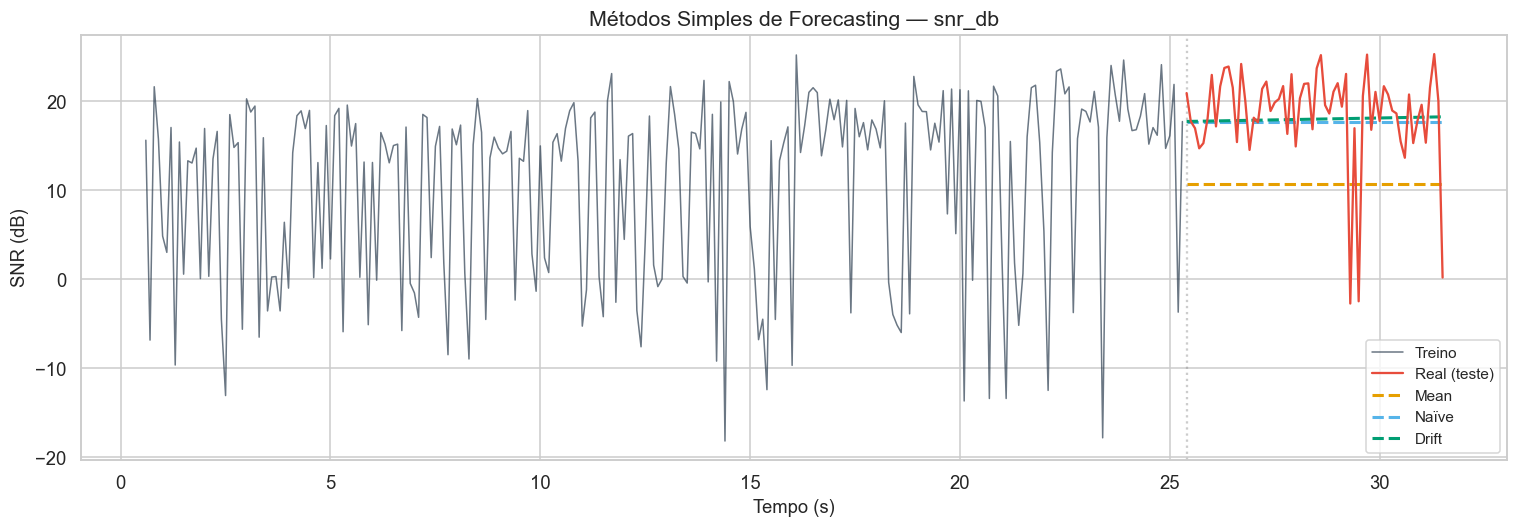

\n→ Observação: Para snr_db (série estocástica), todos os métodos simples
  falham visivelmente — o sinal é dominado por ruído não-previsível.


In [8]:
# ── Previsões para snr_db ──
var_snr = 'snr_db'
train_snr = train[var_snr]
test_snr = test[var_snr]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_train, train_snr, color=COLORS['train'], lw=1, alpha=0.7, label='Treino')
ax.plot(time_test, test_snr, color=COLORS['test'], lw=1.5, label='Real (teste)', zorder=5)

for name, m in METHODS.items():
    fc = m['forecast'](train_snr, h)
    ax.plot(time_test, fc, color=m['color'], ls='--', lw=2, label=f'{name}')

ax.axvline(time_test[0], color='gray', ls=':', alpha=0.4)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('SNR (dB)')
ax.set_title(f'Métodos Simples de Forecasting — {var_snr}')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print("\\n→ Observação: Para snr_db (série estocástica), todos os métodos simples")
print("  falham visivelmente — o sinal é dominado por ruído não-previsível.")

## 3. Valores Ajustados e Resíduos (§5.3)

Os **valores ajustados** (*fitted values*) $\hat{y}_{t|t-1}$ são previsões *in-sample* de um passo à frente, usando apenas dados até $t-1$.

Os **resíduos** medem o erro de previsão de um passo:

$$e_t = y_t - \hat{y}_{t|t-1}$$

No contexto radar, os resíduos representam a **inovação** — a informação nova que o modelo não conseguiu prever. Se o modelo é bom, os resíduos devem se comportar como **ruído branco**.

In [9]:
# ── Cálculo dos resíduos para cada método (TGT_01_pos_x) ──
residuals_px = {}
for name, m in METHODS.items():
    fitted = m['fitted'](train_vals)
    residuals_px[name] = (train_vals - fitted).dropna()

# ── Cálculo dos resíduos para snr_db ──
residuals_snr = {}
for name, m in METHODS.items():
    fitted = m['fitted'](train_snr)
    residuals_snr[name] = (train_snr - fitted).dropna()

# Resumo estatístico dos resíduos
print("═══ Resíduos — TGT_01_pos_x ═══")
for name, res in residuals_px.items():
    print(f"  {name:6s} │ μ={res.mean():+8.2f}  σ={res.std():8.2f}  n={len(res)}")

print("\n═══ Resíduos — snr_db ═══")
for name, res in residuals_snr.items():
    print(f"  {name:6s} │ μ={res.mean():+8.2f}  σ={res.std():8.2f}  n={len(res)}")

═══ Resíduos — TGT_01_pos_x ═══
  Mean   │ μ=-2500.00  σ= 1428.94  n=247
  Naïve  │ μ=  -40.00  σ=    0.00  n=247
  Drift  │ μ=   -0.16  σ=    2.55  n=247

═══ Resíduos — snr_db ═══
  Mean   │ μ=   +1.36  σ=   10.48  n=247
  Naïve  │ μ=   +0.01  σ=   14.57  n=247
  Drift  │ μ=   +0.21  σ=   14.95  n=247


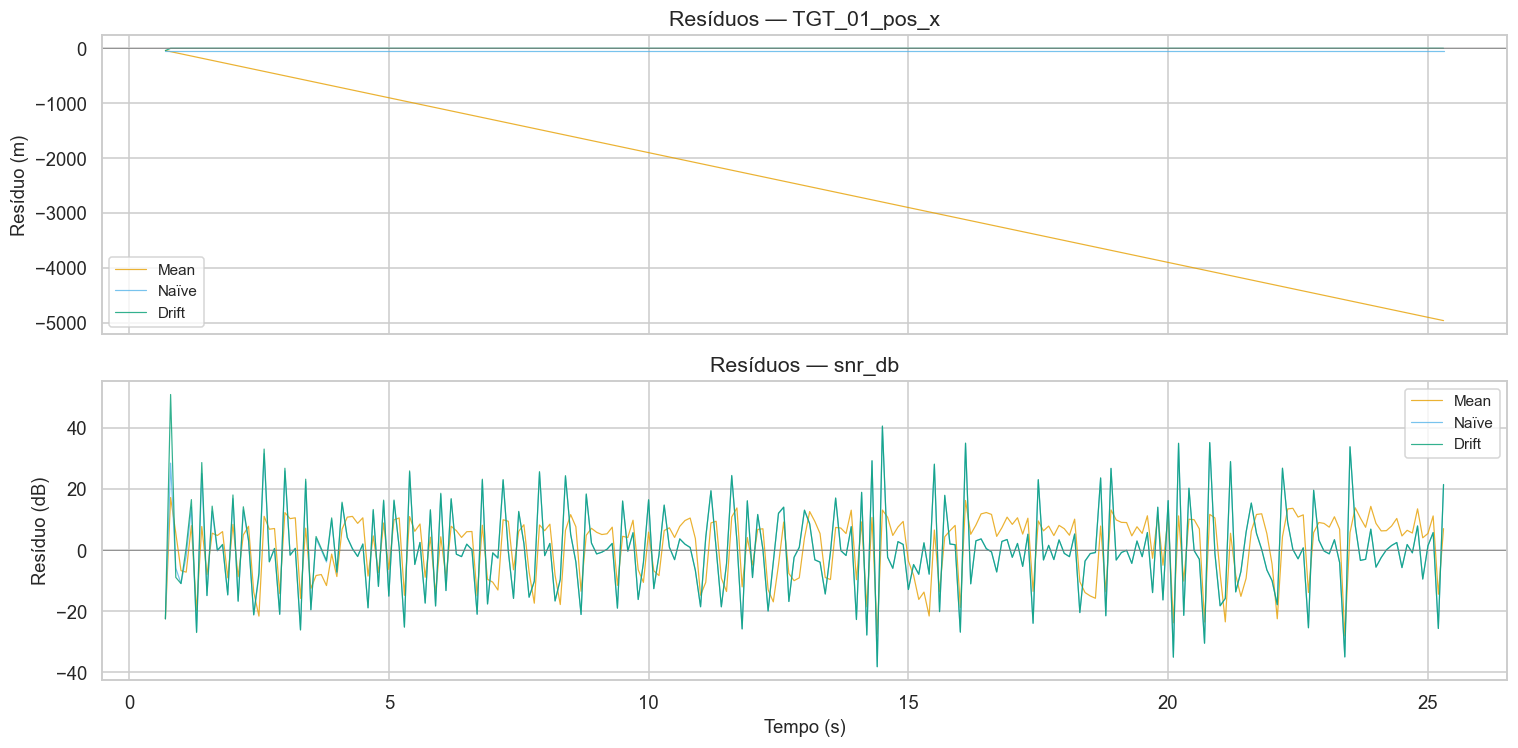

In [10]:
# ── Gráfico temporal dos resíduos ──
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for name, m in METHODS.items():
    res_px = residuals_px[name]
    t_res = train['time'].iloc[-len(res_px):].values
    axes[0].plot(t_res, res_px.values, color=m['color'], lw=0.8, alpha=0.8, label=name)

axes[0].axhline(0, color='gray', ls='-', lw=0.5)
axes[0].set_ylabel('Resíduo (m)')
axes[0].set_title('Resíduos — TGT_01_pos_x')
axes[0].legend(fontsize=10)

for name, m in METHODS.items():
    res_s = residuals_snr[name]
    t_res = train['time'].iloc[-len(res_s):].values
    axes[1].plot(t_res, res_s.values, color=m['color'], lw=0.8, alpha=0.8, label=name)

axes[1].axhline(0, color='gray', ls='-', lw=0.5)
axes[1].set_ylabel('Resíduo (dB)')
axes[1].set_title('Resíduos — snr_db')
axes[1].set_xlabel('Tempo (s)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4. Diagnósticos de Resíduos (§5.4)

Um bom modelo de previsão deve produzir resíduos com as seguintes propriedades:

1. **Não correlacionados** — o ACF não deve apresentar autocorrelações significativas
2. **Média zero** — resíduos com viés indicam previsão sistematicamente errada
3. *(Desejável)* **Variância constante** (homocedasticidade)
4. *(Desejável)* **Distribuição normal** — necessário para intervalos de predição válidos

### Teste de Ljung-Box

$$Q^* = T(T+2) \sum_{k=1}^{\ell} \frac{r_k^2}{T-k}$$

- $H_0$: os resíduos são ruído branco (não correlacionados)
- Se $p$-value $< 0.05$: rejeita $H_0$ → resíduos contêm informação não capturada

In [11]:
def diagnose_residuals(residuals, model_name, lags=15, color='#CC79A7'):
    """Painel diagnostico 2x2: time plot, ACF, histograma, QQ-plot."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Diagnosticos de Residuos - {model_name}', fontsize=14, y=1.01)

    # 1. Time plot
    axes[0, 0].plot(residuals.values, color=color, lw=0.8)
    axes[0, 0].axhline(0, color='gray', ls='-', lw=0.5)
    axes[0, 0].set_title('Residuos ao Longo do Tempo')
    axes[0, 0].set_xlabel('Indice')
    axes[0, 0].set_ylabel('Residuo')

    # 2. ACF
    plot_acf(residuals.values, ax=axes[0, 1], lags=lags,
             color=COLORS['acf_bar'], vlines_kwargs={'colors': COLORS['acf_bar']},
             title='Autocorrelacao (ACF)')

    # 3. Histograma + curva normal
    axes[1, 0].hist(residuals.values, bins=25, density=True, color=color, alpha=0.6, edgecolor='white')
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'k-', lw=1.5, label=f'N({mu:.1f}, {sigma:.1f}^2)')
    axes[1, 0].set_title('Histograma dos Residuos')
    axes[1, 0].legend(fontsize=9)

    # 4. QQ-Plot
    stats.probplot(residuals.values, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('QQ-Plot (Normal)')
    axes[1, 1].get_lines()[0].set_color(color)
    axes[1, 1].get_lines()[1].set_color('gray')

    plt.tight_layout()
    plt.show()

    # Ljung-Box
    lb = acorr_ljungbox(residuals.values, lags=[10], return_df=True)
    p_val = lb['lb_pvalue'].values[0]
    verdict = 'Ruido branco' if p_val > 0.05 else 'Autocorrelacao detectada'
    print(f'  Ljung-Box (lag=10): Q*={lb["lb_stat"].values[0]:.2f}, p-value={p_val:.4f} -> {verdict}')
    return p_val

print("Funcao diagnose_residuals() definida.")

Funcao diagnose_residuals() definida.


DIAGNÓSTICOS DE RESÍDUOS — TGT_01_pos_x

▸ Método: Mean


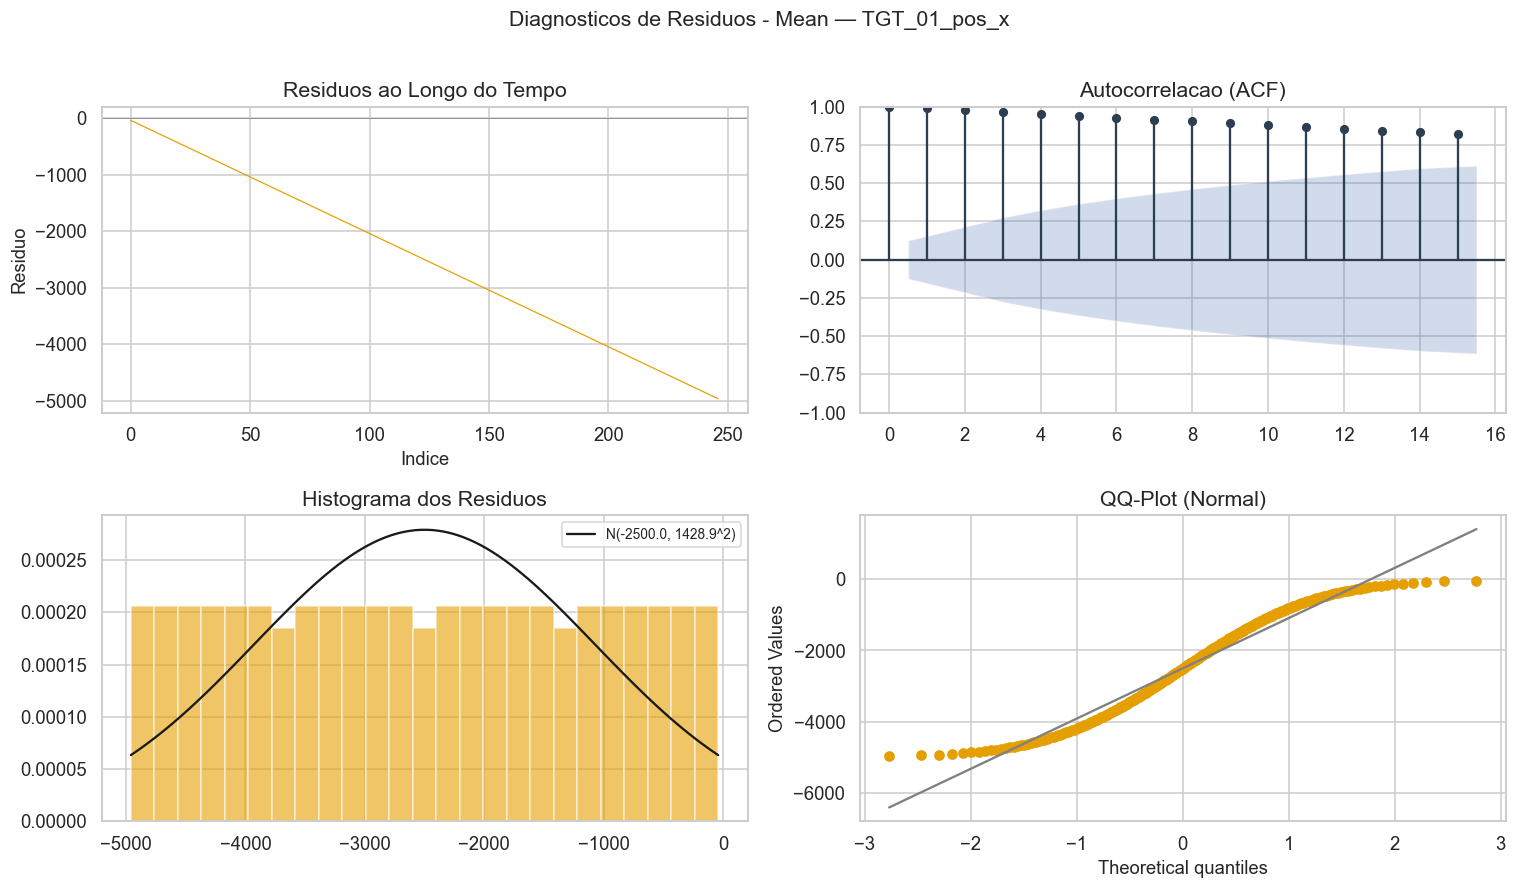

  Ljung-Box (lag=10): Q*=2219.45, p-value=0.0000 -> Autocorrelacao detectada

▸ Método: Naïve


C:\Users\rw17\miniconda3\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
C:\Users\rw17\miniconda3\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2076: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


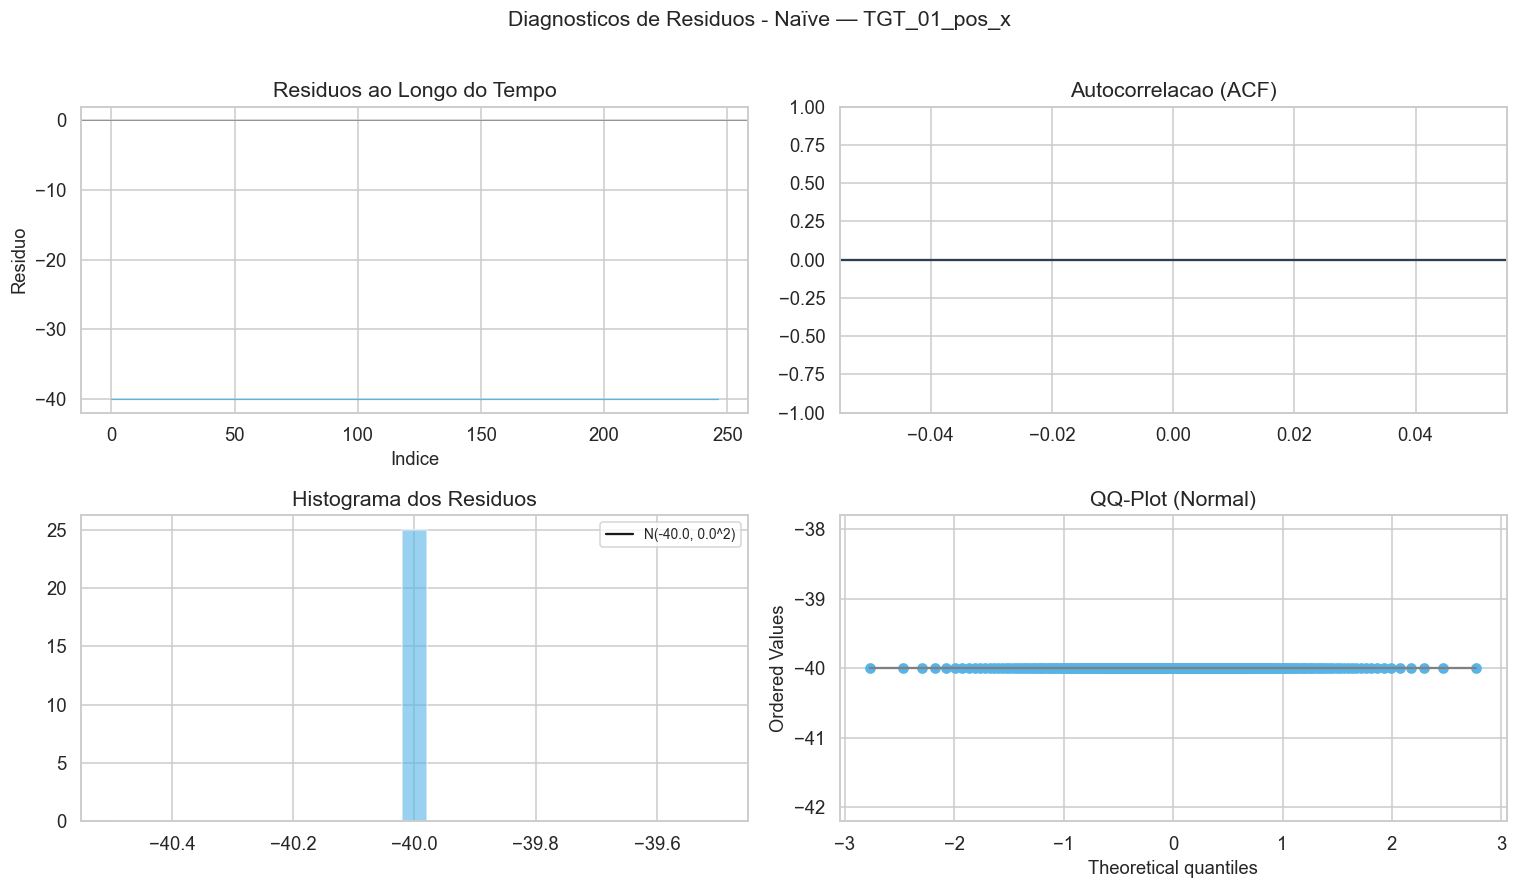

  Ljung-Box (lag=10): Q*=nan, p-value=nan -> Autocorrelacao detectada

▸ Método: Drift


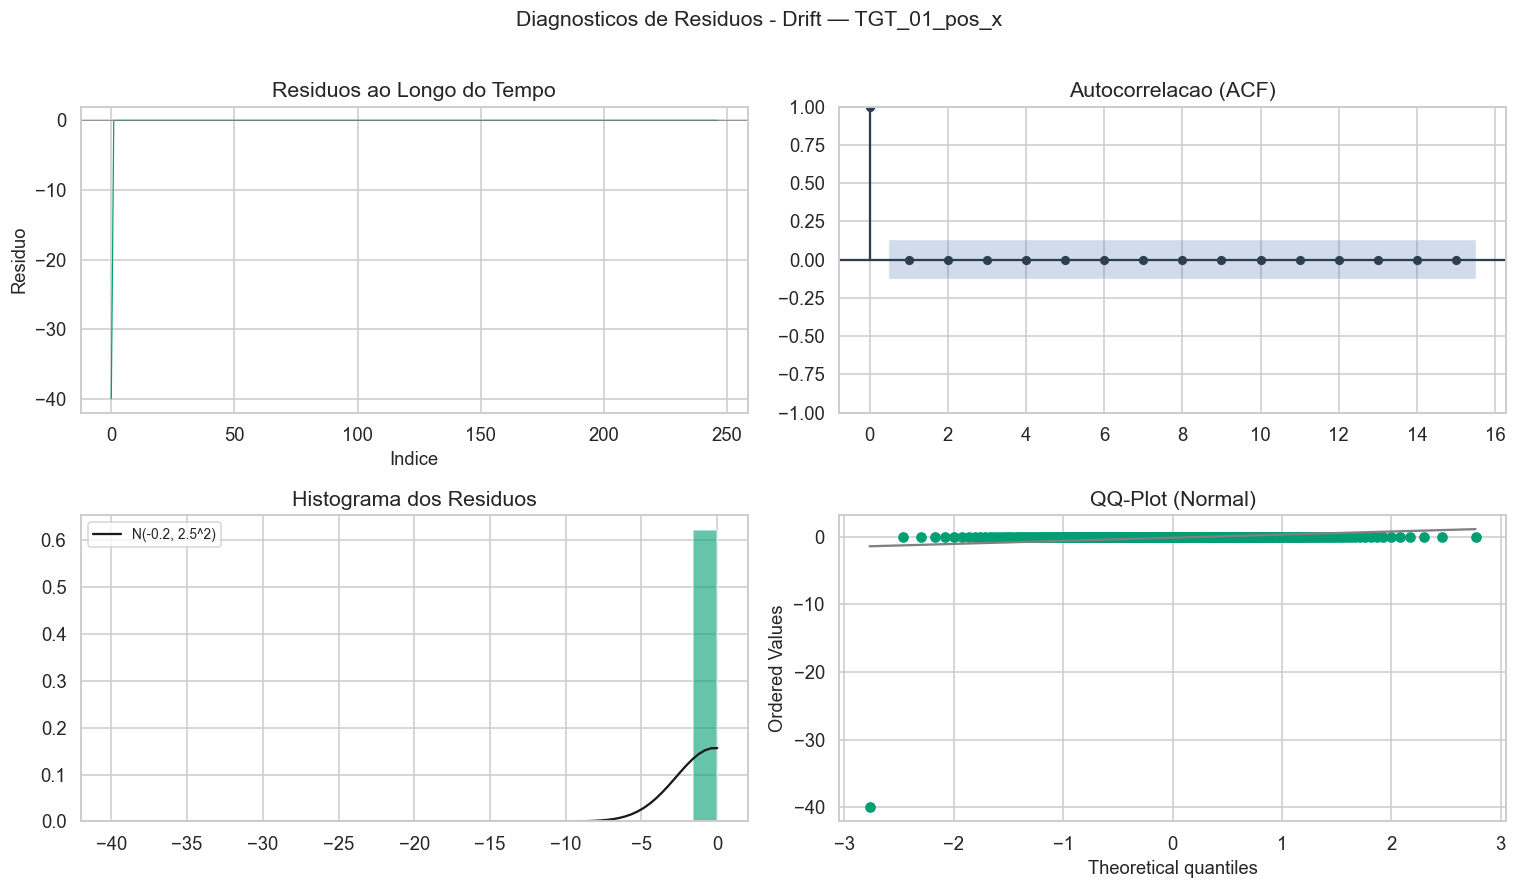

  Ljung-Box (lag=10): Q*=0.00, p-value=1.0000 -> Ruido branco


In [12]:
# ── Diagnósticos — TGT_01_pos_x ──
print("=" * 60)
print("DIAGNÓSTICOS DE RESÍDUOS — TGT_01_pos_x")
print("=" * 60)
lb_results_px = {}
for name, m in METHODS.items():
    print(f"\n▸ Método: {name}")
    p = diagnose_residuals(residuals_px[name], f'{name} — TGT_01_pos_x',
                           color=m['color'])
    lb_results_px[name] = p

DIAGNÓSTICOS DE RESÍDUOS — snr_db

▸ Método: Mean


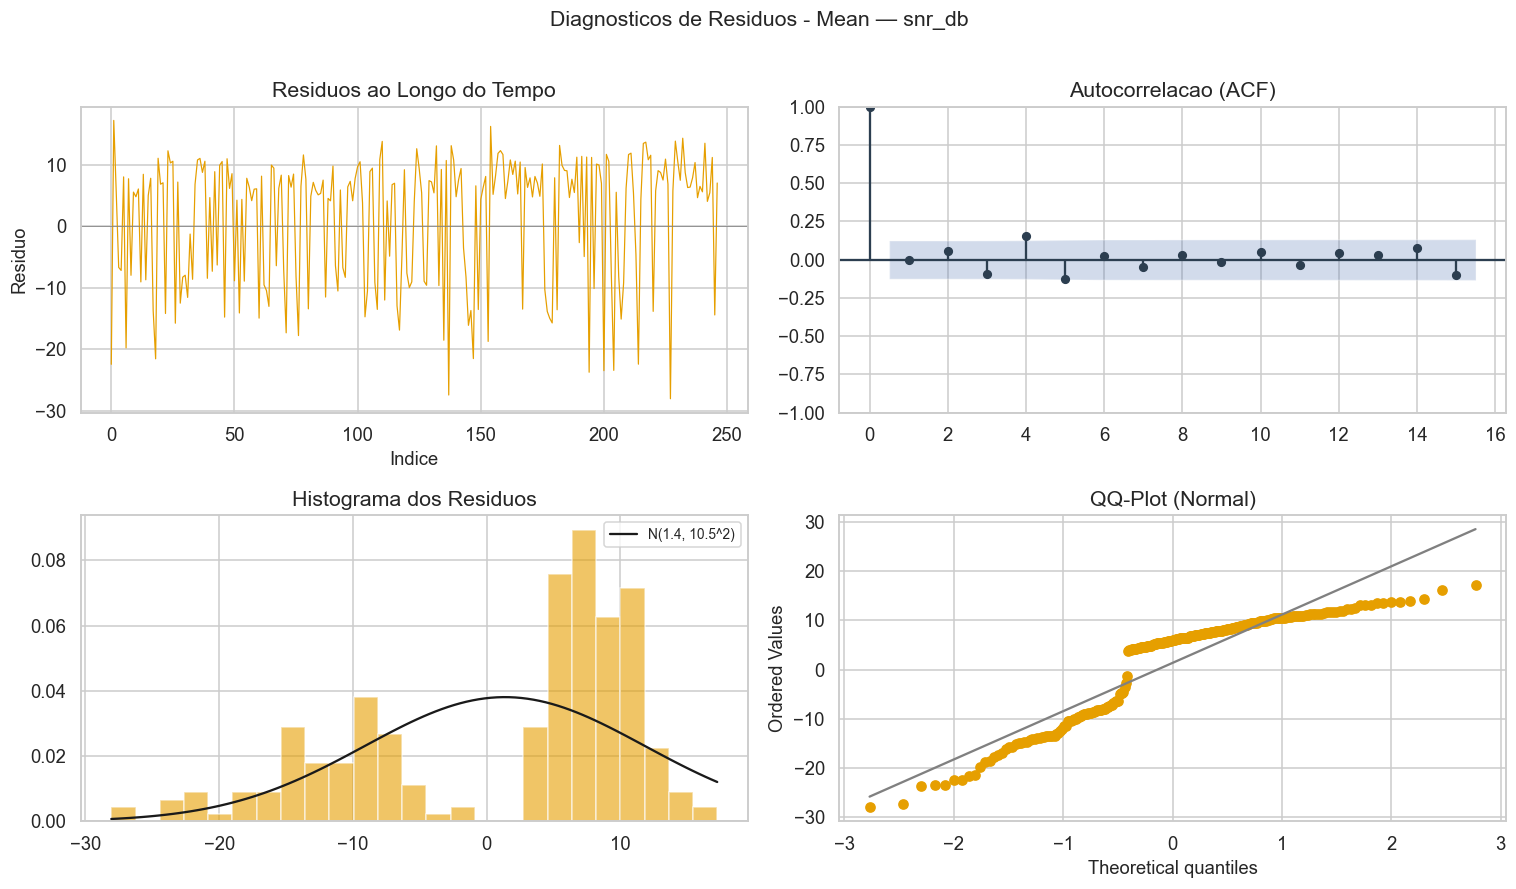

  Ljung-Box (lag=10): Q*=14.94, p-value=0.1344 -> Ruido branco

▸ Método: Naïve


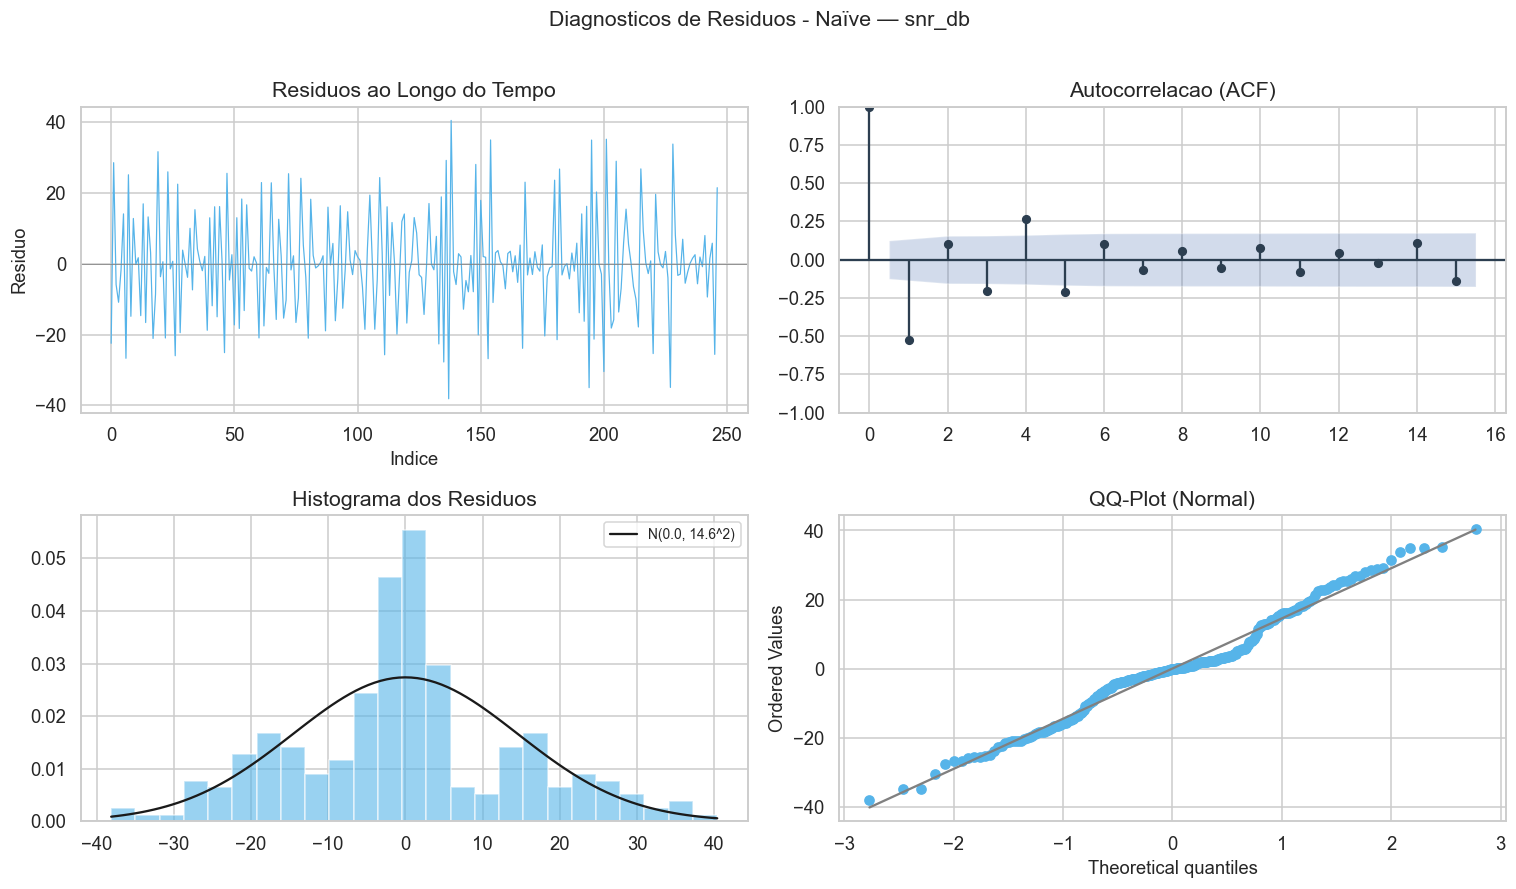

  Ljung-Box (lag=10): Q*=118.17, p-value=0.0000 -> Autocorrelacao detectada

▸ Método: Drift


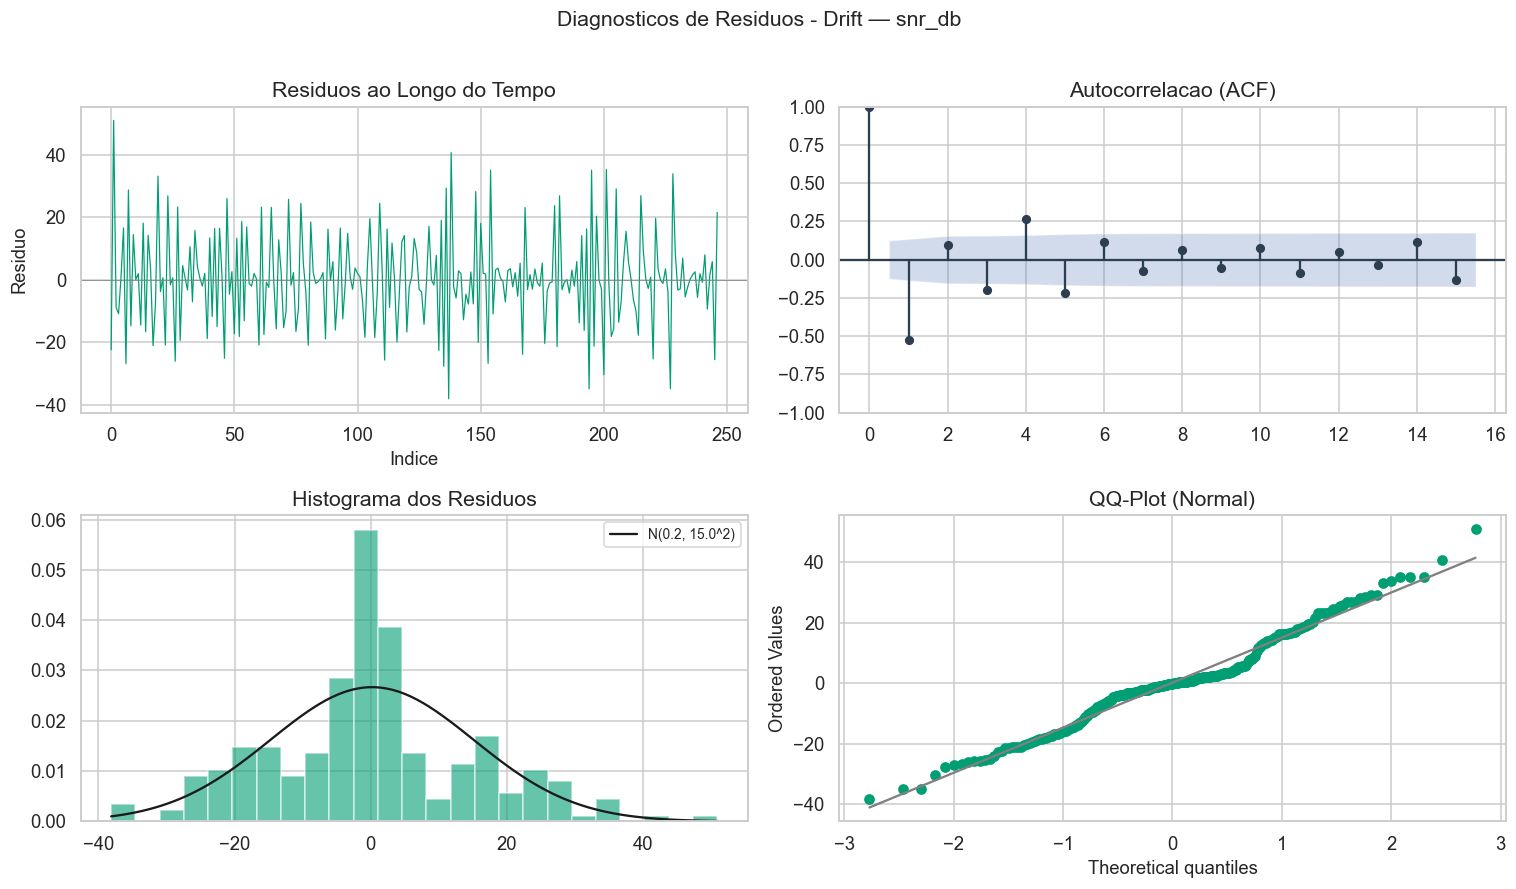

  Ljung-Box (lag=10): Q*=118.11, p-value=0.0000 -> Autocorrelacao detectada


In [13]:
# ── Diagnósticos — snr_db ──
print("=" * 60)
print("DIAGNÓSTICOS DE RESÍDUOS — snr_db")
print("=" * 60)
lb_results_snr = {}
for name, m in METHODS.items():
    print(f"\n▸ Método: {name}")
    p = diagnose_residuals(residuals_snr[name], f'{name} — snr_db',
                           color=m['color'])
    lb_results_snr[name] = p

In [14]:
# ── Tabela resumo do teste de Ljung-Box ──
lb_df = pd.DataFrame({
    'Método': list(METHODS.keys()),
    'p-value (pos_x)': [lb_results_px[m] for m in METHODS],
    'p-value (snr_db)': [lb_results_snr[m] for m in METHODS],
})
lb_df['Veredicto pos_x'] = lb_df['p-value (pos_x)'].apply(
    lambda p: '✓ Branco' if p > 0.05 else '✗ Correlacionado')
lb_df['Veredicto snr_db'] = lb_df['p-value (snr_db)'].apply(
    lambda p: '✓ Branco' if p > 0.05 else '✗ Correlacionado')

print("═══ Teste de Ljung-Box (lag=10, α=0.05) ═══\n")
print(lb_df.to_string(index=False, float_format='{:.4f}'.format))
print("\n→ Se p-value < 0.05, os resíduos NÃO são ruído branco —")
print("  o modelo deixou informação previsível nos resíduos.")

═══ Teste de Ljung-Box (lag=10, α=0.05) ═══

Método  p-value (pos_x)  p-value (snr_db)  Veredicto pos_x Veredicto snr_db
  Mean           0.0000            0.1344 ✗ Correlacionado         ✓ Branco
 Naïve              NaN            0.0000 ✗ Correlacionado ✗ Correlacionado
 Drift           1.0000            0.0000         ✓ Branco ✗ Correlacionado

→ Se p-value < 0.05, os resíduos NÃO são ruído branco —
  o modelo deixou informação previsível nos resíduos.


## 5. Avaliação de Acurácia Preditiva (§5.8)

A acurácia é avaliada no **conjunto de teste** (out-of-sample). Métricas utilizadas:

| Métrica | Fórmula | Propriedade |
|---------|---------|-------------|
| **MAE** | $\frac{1}{h}\sum\|e_i\|$ | Escala original, robusta a outliers |
| **RMSE** | $\sqrt{\frac{1}{h}\sum e_i^2}$ | Penaliza erros grandes |
| **MASE** | $\frac{\text{MAE}}{Q}$, onde $Q = \frac{1}{T-1}\sum_{t=2}^{T}\|y_t - y_{t-1}\|$ | **Escala-independente** — métrica preferida pelo FPP3 |

> **Interpretação do MASE**: Valor < 1 indica que o modelo é **melhor** que o Naïve in-sample. Valor > 1 indica que o modelo é **pior** que a persistência ingênua.

In [15]:
def compute_accuracy(actual, forecast, train_vals):
    """Calcula MAE, RMSE e MASE para previsoes out-of-sample."""
    errors = actual.values - forecast
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    # MASE: escala = MAE do naive in-sample
    naive_errors = np.abs(np.diff(train_vals.values))
    scale = np.mean(naive_errors)
    mase = mae / scale if scale > 0 else np.inf
    return {'MAE': f'{mae:.2f}', 'RMSE': f'{rmse:.2f}', 'MASE': f'{mase:.4f}',
            'MAE_raw': mae, 'RMSE_raw': rmse, 'MASE_raw': mase}

print("Funcao compute_accuracy() definida.")

Funcao compute_accuracy() definida.


In [16]:
# ── Tabela de acurácia ──
results = []
for var_name, tv, te, tr in [('TGT_01_pos_x', train_vals, test_vals, train_vals),
                               ('snr_db', train_snr, test_snr, train_snr)]:
    for mname, m in METHODS.items():
        fc = m['forecast'](tv, len(te))
        acc = compute_accuracy(te, fc, tv)
        results.append({'Variável': var_name, 'Método': mname,
                        'MAE': acc['MAE'], 'RMSE': acc['RMSE'], 'MASE': acc['MASE'],
                        'MASE_raw': acc['MASE_raw']})

acc_df = pd.DataFrame(results)
print("═══ Acurácia Preditiva — Conjunto de Teste ═══\n")
print(acc_df[['Variável', 'Método', 'MAE', 'RMSE', 'MASE']].to_string(index=False))

═══ Acurácia Preditiva — Conjunto de Teste ═══

    Variável Método     MAE    RMSE     MASE
TGT_01_pos_x   Mean 6199.35 6240.42 154.9839
TGT_01_pos_x  Naïve 1259.35 1448.04  31.4839
TGT_01_pos_x  Drift    0.65    5.08   0.0161
      snr_db   Mean    9.13    9.62   0.8471
      snr_db  Naïve    3.76    5.51   0.3489
      snr_db  Drift    3.68    5.50   0.3415


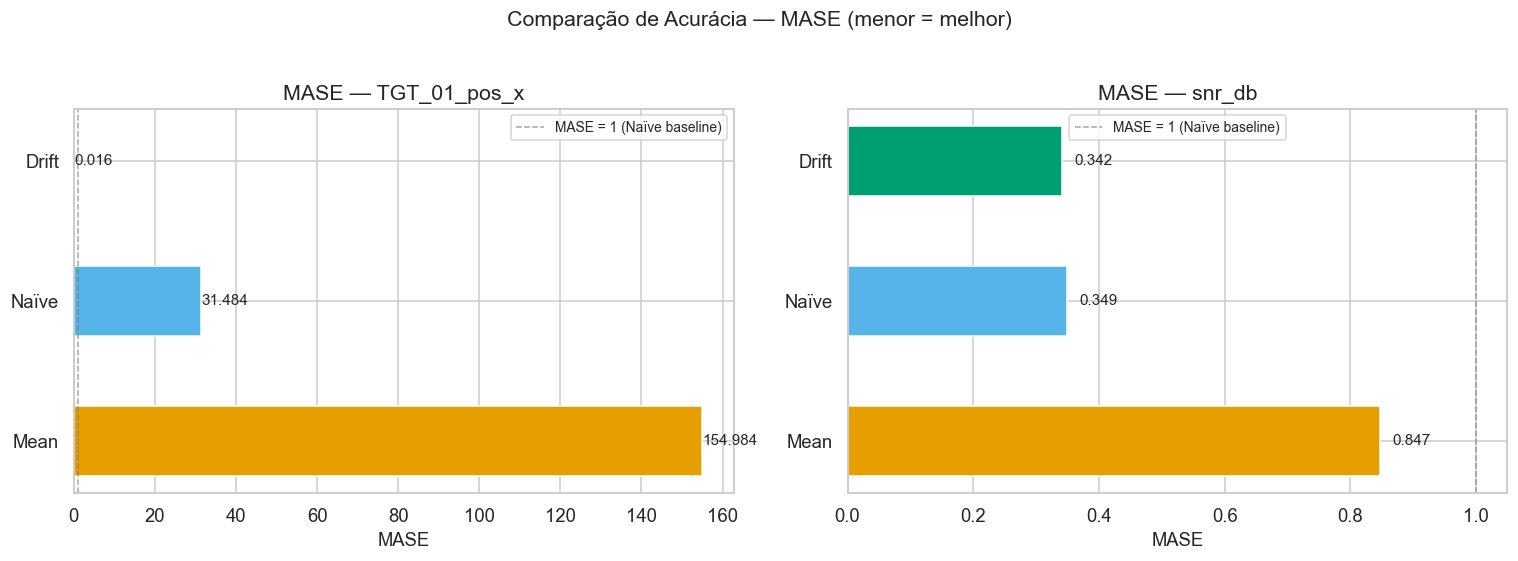


→ MASE < 1: modelo supera o Naïve (benchmark).
→ MASE = 1: modelo equivalente ao Naïve.
→ MASE > 1: modelo pior que simplesmente repetir o último valor.


In [17]:
# ── Comparação visual (MASE) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for idx, var_name in enumerate(['TGT_01_pos_x', 'snr_db']):
    sub = acc_df[acc_df['Variável'] == var_name]
    colors_bar = [METHODS[m]['color'] for m in sub['Método']]
    bars = axes[idx].barh(sub['Método'], sub['MASE_raw'], color=colors_bar, edgecolor='white', height=0.5)
    axes[idx].axvline(1.0, color='gray', ls='--', lw=1, alpha=0.7, label='MASE = 1 (Naïve baseline)')
    axes[idx].set_xlabel('MASE')
    axes[idx].set_title(f'MASE — {var_name}')
    axes[idx].legend(fontsize=9)
    # Valor nas barras
    for bar, val in zip(bars, sub['MASE_raw']):
        axes[idx].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                       f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Comparação de Acurácia — MASE (menor = melhor)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n→ MASE < 1: modelo supera o Naïve (benchmark).")
print("→ MASE = 1: modelo equivalente ao Naïve.")
print("→ MASE > 1: modelo pior que simplesmente repetir o último valor.")

## 6. Validação Cruzada de Séries Temporais — TSCV (§5.10)

A validação cruzada temporal avalia a **robustez** do modelo ao longo de diferentes pontos de origem:

```
Treino: [──────●]                    → Previsão h passos à frente
Treino: [───────●]                   → Previsão h passos à frente
Treino: [────────●]                  → Previsão h passos à frente
         ...                              ...
```

A cada iteração, a janela de treino **expande** (mantendo o início fixo) e calculamos o erro para o passo $h$. A métrica final é o **RMSE médio** sobre todas as origens.

### Vantagem sobre Train/Test fixo
- Usa **todos os dados** para avaliação
- Captura variação de performance em **diferentes fases** do engajamento

In [18]:
def tscv_rmse(series, method_fn, h=1, min_train=50, step=5):
    """Time Series Cross-Validation com janela expansivel."""
    errors = []
    for t in range(min_train, len(series) - h + 1, step):
        train_cv = series.iloc[:t]
        forecast = method_fn(train_cv, h)
        actual = series.iloc[t + h - 1]
        errors.append((actual - forecast[-1])**2)
    return np.sqrt(np.mean(errors))

print("Funcao tscv_rmse() definida.")

Funcao tscv_rmse() definida.


In [19]:
# ── TSCV para múltiplos horizontes ──
horizons = [1, 5, 10, 20]
series_px = df_conf['TGT_01_pos_x'].reset_index(drop=True)
series_snr = df_conf['snr_db'].reset_index(drop=True)

tscv_results = []
for h_val in horizons:
    for mname, m in METHODS.items():
        rmse_px = tscv_rmse(series_px, m['forecast'], h=h_val, min_train=50, step=3)
        rmse_snr = tscv_rmse(series_snr, m['forecast'], h=h_val, min_train=50, step=3)
        tscv_results.append({'h': h_val, 'Método': mname,
                             'RMSE_pos_x': rmse_px, 'RMSE_snr': rmse_snr})

tscv_df = pd.DataFrame(tscv_results)
print("═══ TSCV — RMSE por Horizonte ═══\n")
for h_val in horizons:
    print(f"─── h = {h_val} ({h_val*0.1:.1f}s) ───")
    sub = tscv_df[tscv_df['h'] == h_val]
    for _, row in sub.iterrows():
        print(f"  {row['Método']:6s} │ pos_x: {row['RMSE_pos_x']:10.2f} m  │ snr_db: {row['RMSE_snr']:.2f} dB")
    print()

═══ TSCV — RMSE por Horizonte ═══

─── h = 1 (0.1s) ───
  Mean   │ pos_x:    3902.61 m  │ snr_db: 9.81 dB
  Naïve  │ pos_x:      40.00 m  │ snr_db: 12.06 dB
  Drift  │ pos_x:       0.00 m  │ snr_db: 12.10 dB

─── h = 5 (0.5s) ───
  Mean   │ pos_x:    4015.67 m  │ snr_db: 10.63 dB
  Naïve  │ pos_x:     199.58 m  │ snr_db: 14.57 dB
  Drift  │ pos_x:       4.31 m  │ snr_db: 14.80 dB

─── h = 10 (1.0s) ───
  Mean   │ pos_x:    4134.42 m  │ snr_db: 9.83 dB
  Naïve  │ pos_x:     400.00 m  │ snr_db: 11.48 dB
  Drift  │ pos_x:       0.00 m  │ snr_db: 11.96 dB

─── h = 20 (2.0s) ───
  Mean   │ pos_x:    4408.39 m  │ snr_db: 10.83 dB
  Naïve  │ pos_x:     799.52 m  │ snr_db: 12.19 dB
  Drift  │ pos_x:       4.44 m  │ snr_db: 13.01 dB



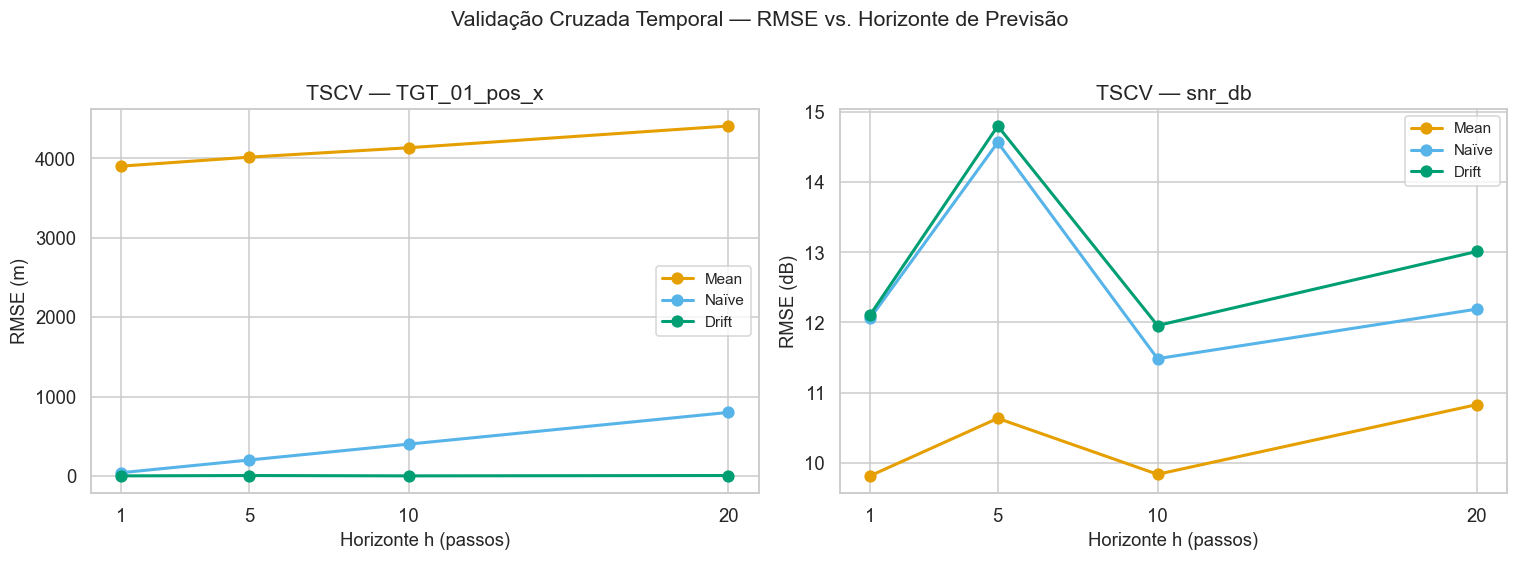

→ Para pos_x: Drift mantém RMSE baixo → extrapolação linear é adequada.
→ Para snr_db: todos os métodos degradam igualmente → ruído é imprevisível.


In [20]:
# ── Visualização TSCV: RMSE vs. Horizonte ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mname, m in METHODS.items():
    sub = tscv_df[tscv_df['Método'] == mname]
    axes[0].plot(sub['h'], sub['RMSE_pos_x'], 'o-', color=m['color'], lw=2, ms=7, label=mname)
    axes[1].plot(sub['h'], sub['RMSE_snr'], 'o-', color=m['color'], lw=2, ms=7, label=mname)

axes[0].set_xlabel('Horizonte h (passos)')
axes[0].set_ylabel('RMSE (m)')
axes[0].set_title('TSCV — TGT_01_pos_x')
axes[0].legend(fontsize=10)
axes[0].set_xticks(horizons)

axes[1].set_xlabel('Horizonte h (passos)')
axes[1].set_ylabel('RMSE (dB)')
axes[1].set_title('TSCV — snr_db')
axes[1].legend(fontsize=10)
axes[1].set_xticks(horizons)

plt.suptitle('Validação Cruzada Temporal — RMSE vs. Horizonte de Previsão', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("→ Para pos_x: Drift mantém RMSE baixo → extrapolação linear é adequada.")
print("→ Para snr_db: todos os métodos degradam igualmente → ruído é imprevisível.")

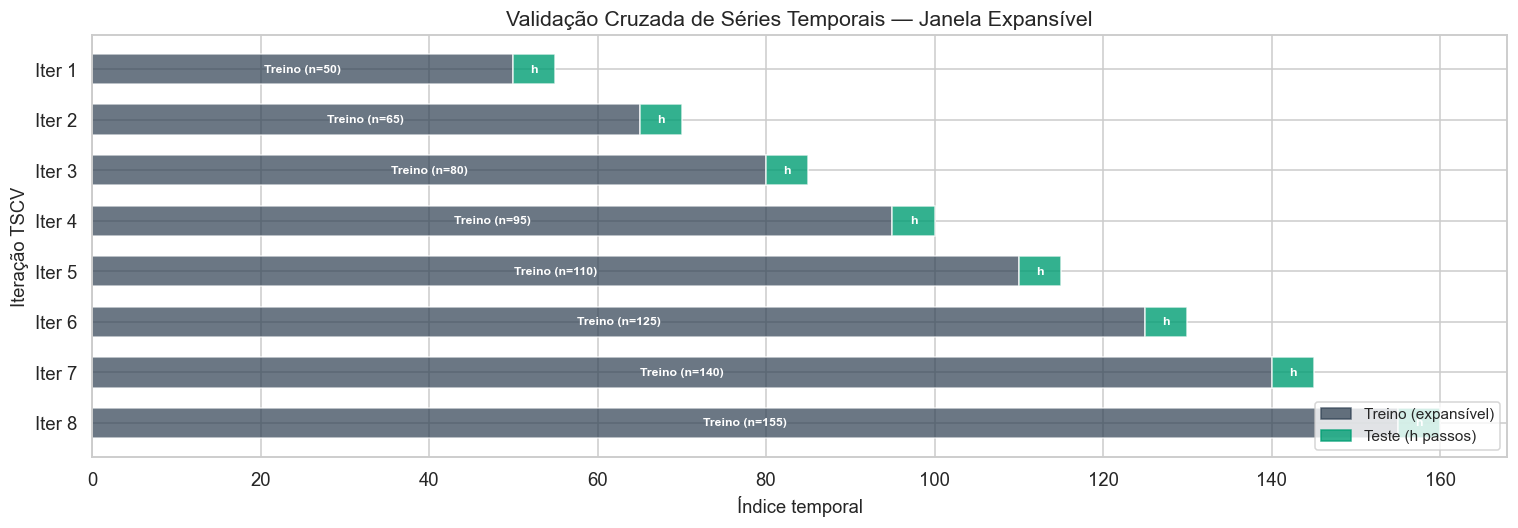

In [21]:
# ── Diagrama visual do processo TSCV ──
fig, ax = plt.subplots(figsize=(14, 5))

n_origins = 8
min_t = 50
step_show = 15
max_t = min_t + n_origins * step_show

for i in range(n_origins):
    t = min_t + i * step_show
    y = n_origins - i
    # Treino
    ax.barh(y, t, height=0.6, color=COLORS['train'], alpha=0.7, edgecolor='white')
    # Teste (h=5 passos)
    ax.barh(y, 5, left=t, height=0.6, color=COLORS['forecast_drift'], alpha=0.8, edgecolor='white')
    ax.text(t/2, y, f'Treino (n={t})', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(t+2.5, y, f'h', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Índice temporal')
ax.set_ylabel('Iteração TSCV')
ax.set_title('Validação Cruzada de Séries Temporais — Janela Expansível')
ax.set_yticks(range(1, n_origins + 1))
ax.set_yticklabels([f'Iter {n_origins - i}' for i in range(n_origins)])

# Legenda
legend_elements = [
    mpatches.Patch(color=COLORS['train'], alpha=0.7, label='Treino (expansível)'),
    mpatches.Patch(color=COLORS['forecast_drift'], alpha=0.8, label='Teste (h passos)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Conclusões e Interpretação Radar

### Resumo dos Resultados

| Achado | Implicação para o Radar |
|--------|------------------------|
| **Drift domina em `pos_x`** | Extrapolação linear captura a trajetória balística do alvo — esperado para voo retilíneo |
| **Todos falham em `snr_db`** | Flutuações do SNR são essencialmente ruído branco — nenhum método simples captura a dinâmica estocástica |
| **MASE ≈ 1 para Naïve em `pos_x`** | A posição muda de forma suave e previsível — persistência é um baseline competitivo |
| **TSCV confirma Train/Test** | Resultados robustos ao longo de diferentes fases do engajamento |

### Interpretação Operacional

> **Regra prática**: Um filtro de rastreamento (Alpha-Beta, Kalman) que não consegue MASE < 1 para `pos_x` não está adicionando valor ao sistema de armas — a simples extrapolação linear (Drift) seria suficiente.

### Próximos Passos (Capítulos seguintes)

- **Cap 7 — Regressão com Séries Temporais**: Modelar `pos_x` como função de variáveis exógenas (velocidade, ângulo)
- **Cap 8 — Suavização Exponencial**: Aplicar ETS aos dados de radar para capturar tendência com adaptação
- **Cap 9 — ARIMA**: Modelar `snr_db` como processo autorregressivo integrado

---

*Notebook gerado como parte do projeto Glaukopis — Análise de Séries Temporais de Engajamento Radar BVR.*